In [1]:
import math
import numpy as np
import pandas as pd
import yfinance as yf
import datetime as dt
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns
# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

In [2]:
# Fetching Market Data

from typing import Dict, Tuple, Optional

def calculate_historical_volatility(ticker: str, period: str = '1y', 
                                    window: int = 21) -> Tuple[float, float, pd.DataFrame]:
    """
    Calculate historical volatility and dividend yield from market data.
    
    Parameters:
    -----------
    ticker : Stock ticker symbol
    period : Historical data period (e.g., '1y')
    window : Rolling window for volatility calculation (default 21 trading days)
    
    Returns:
    --------
    Tuple[float, float, DataFrame] : (annualized_volatility, dividend_yield, price_data)
    """
    
    # Fetch historical data
    stock = yf.Ticker(ticker)
    df = stock.history(period=period)
    
    # Calculate log returns
    df['LogReturn'] = np.log(df['Close'] / df['Close'].shift(1))
    
    # Calculate rolling volatility (annualized)
    df['Volatility'] = df['LogReturn'].rolling(window=window).std() * np.sqrt(252)
    
    # Get most recent annualized volatility
    current_volatility = df['Volatility'].dropna().iloc[-1]
    
    # Calculate dividend yield
    dividends = df['Dividends']
    recent_dividends = dividends[dividends.index > (dividends.index.max() - pd.DateOffset(years=1))].sum()
    dividend_yield = recent_dividends / df['Close'].iloc[-1] if df['Close'].iloc[-1] > 0 else 0.0
    
    return current_volatility, dividend_yield, df


def get_risk_free_rate() -> float:
    """
    Get current risk-free rate (1-year Treasury).
    Falls back to default if data unavailable.
    """
    
    import pandas_datareader as pdr
    rf_data = pdr.DataReader('DGS1', 'fred')
    return rf_data['DGS1'].dropna().iloc[-1] / 100


def fetch_option_chain(ticker: str) -> pd.DataFrame:
    """
    Fetch complete option chain for a ticker with enhanced data processing.
    
    Returns:
    --------
    DataFrame : Complete option chain with calls and puts
    """
    
    asset = yf.Ticker(ticker)
    expiration_dates = asset.options
    
    all_chains = []
    
    for expiration in expiration_dates:
        opt = asset.option_chain(expiration)
        
        # Process calls
        calls = opt.calls.copy()
        calls['optionType'] = 'call'
        
        # Process puts
        puts = opt.puts.copy()
        puts['optionType'] = 'put'
        
        # Combine
        chain = pd.concat([calls, puts], ignore_index=True)
        chain['expiration'] = pd.to_datetime(expiration) + pd.DateOffset(hours=23, minutes=59, seconds=59)
        
        all_chains.append(chain)
    
    # Combine all chains
    complete_chain = pd.concat(all_chains, ignore_index=True)
    
    # Calculate days to expiration
    complete_chain['daysToExpiration'] = (complete_chain['expiration'] - dt.datetime.today()).dt.days + 1
    
    # Add moneyness
    current_price = yf.Ticker(ticker).history(period='1d')['Close'].iloc[-1]
    complete_chain['moneyness'] = complete_chain['strike'] / current_price
    
    return complete_chain


In [3]:
# Analytical Greeks (Black-Scholes)

def d1_d2(S: float, K: float, T: float, sigma: float, r: float, q: float = 0.0) -> Tuple[float, float]:
    """
    Calculate d1 and d2 for Black-Scholes formula.
    """
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return d1, d2


class AnalyticalGreeks:
    """
    Calculate all Greeks using Black-Scholes analytical formulas.
    """
    
    @staticmethod
    def delta(S: float, K: float, T: float, sigma: float, r: float, 
              option_type: str = 'call', q: float = 0.0) -> float:
        """
        Delta: ∂V/∂S
        Rate of change of option price with respect to underlying price.
        """
        d1, _ = d1_d2(S, K, T, sigma, r, q)
        
        if option_type.lower() == 'call':
            return np.exp(-q * T) * norm.cdf(d1)
        else:
            return np.exp(-q * T) * (norm.cdf(d1) - 1)
    
    @staticmethod
    def gamma(S: float, K: float, T: float, sigma: float, r: float, q: float = 0.0) -> float:
        """
        Gamma: ∂²V/∂S²
        Rate of change of delta with respect to underlying price.
        Same for calls and puts.
        """
        d1, _ = d1_d2(S, K, T, sigma, r, q)
        return np.exp(-q * T) * norm.pdf(d1) / (S * sigma * np.sqrt(T))
    
    @staticmethod
    def vega(S: float, K: float, T: float, sigma: float, r: float, q: float = 0.0) -> float:
        """
        Vega: ∂V/∂σ
        Sensitivity to volatility (per 1% change).
        Same for calls and puts.
        """
        d1, _ = d1_d2(S, K, T, sigma, r, q)
        return S * np.exp(-q * T) * norm.pdf(d1) * np.sqrt(T) / 100
    
    @staticmethod
    def theta(S: float, K: float, T: float, sigma: float, r: float,
              option_type: str = 'call', q: float = 0.0, per_day: bool = True) -> float:
        """
        Theta: ∂V/∂t
        Time decay (typically negative).
        
        Parameters:
        -----------
        per_day : If True, return per-day theta (divide by 252)
        """
        d1, d2 = d1_d2(S, K, T, sigma, r, q)
        
        term1 = -S * np.exp(-q * T) * norm.pdf(d1) * sigma / (2 * np.sqrt(T))
        
        if option_type.lower() == 'call':
            term2 = q * S * np.exp(-q * T) * norm.cdf(d1)
            term3 = -r * K * np.exp(-r * T) * norm.cdf(d2)
        else:
            term2 = -q * S * np.exp(-q * T) * norm.cdf(-d1)
            term3 = r * K * np.exp(-r * T) * norm.cdf(-d2)
        
        theta_val = term1 + term2 + term3
        
        return theta_val / 252 if per_day else theta_val
    
    @staticmethod
    def rho(S: float, K: float, T: float, sigma: float, r: float,
            option_type: str = 'call', q: float = 0.0) -> float:
        """
        Rho: ∂V/∂r
        Sensitivity to interest rate (per 1% change).
        """
        _, d2 = d1_d2(S, K, T, sigma, r, q)
        
        if option_type.lower() == 'call':
            return K * T * np.exp(-r * T) * norm.cdf(d2) / 100
        else:
            return -K * T * np.exp(-r * T) * norm.cdf(-d2) / 100
    
    @staticmethod
    def all_greeks(S: float, K: float, T: float, sigma: float, r: float,
                   option_type: str = 'call', q: float = 0.0) -> Dict[str, float]:
        """
        Calculate all Greeks at once.
        """
        return {
            'Delta': AnalyticalGreeks.delta(S, K, T, sigma, r, option_type, q),
            'Gamma': AnalyticalGreeks.gamma(S, K, T, sigma, r, q),
            'Vega': AnalyticalGreeks.vega(S, K, T, sigma, r, q),
            'Theta': AnalyticalGreeks.theta(S, K, T, sigma, r, option_type, q),
            'Rho': AnalyticalGreeks.rho(S, K, T, sigma, r, option_type, q)
        }

# Example 
S, K, T, sigma, r = 100, 100, 0.25, 0.30, 0.05
analytical_greeks = AnalyticalGreeks.all_greeks(S, K, T, sigma, r, 'call')

print(f"\nOption Parameters: S=${S}, K=${K}, T={T}y, σ={sigma}, r={r}")
print("\nCall Option Greeks:")
for greek, value in analytical_greeks.items():
    print(f"  {greek:8s}: {value:10.6f}")


Option Parameters: S=$100, K=$100, T=0.25y, σ=0.3, r=0.05

Call Option Greeks:
  Delta   :   0.562903
  Gamma   :   0.026265
  Vega    :   0.196986
  Theta   :  -0.056764
  Rho     :   0.124268


In [4]:
# Finite Difference Greeks

def black_scholes_price(S: float, K: float, T: float, sigma: float, r: float,
                       option_type: str = 'call', q: float = 0.0) -> float:
    """
    Black-Scholes option pricing formula.
    """
    d1, d2 = d1_d2(S, K, T, sigma, r, q)
    
    if option_type.lower() == 'call':
        return S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)


class FiniteDifferenceGreeks:
    """
    Calculate Greeks using finite difference approximations.
    Works with any option pricing function, e.g., the one using binomial tree.
    """
    
    def __init__(self, pricing_function=black_scholes_price):
        """
        Parameters:
        -----------
        pricing_function : Callable that takes (S, K, T, sigma, r, option_type, q)
        """
        self.pricing_function = pricing_function
    
    def delta(self, S: float, K: float, T: float, sigma: float, r: float,
              option_type: str = 'call', q: float = 0.0, h: float = 0.01) -> float:
        """
        Delta using central difference: [V(S+h) - V(S-h)] / (2h)
        
        Parameters:
        -----------
        h : Step size (default 0.01, i.e., $0.01 or 1 cent)
        """
        V_plus = self.pricing_function(S + h, K, T, sigma, r, option_type, q)
        V_minus = self.pricing_function(S - h, K, T, sigma, r, option_type, q)
        
        return (V_plus - V_minus) / (2 * h)
    
    def gamma(self, S: float, K: float, T: float, sigma: float, r: float,
              option_type: str = 'call', q: float = 0.0, h: float = 0.01) -> float:
        """
        Gamma using central difference: [V(S+h) - 2*V(S) + V(S-h)] / h²
        """
        V_plus = self.pricing_function(S + h, K, T, sigma, r, option_type, q)
        V_center = self.pricing_function(S, K, T, sigma, r, option_type, q)
        V_minus = self.pricing_function(S - h, K, T, sigma, r, option_type, q)
        
        return (V_plus - 2 * V_center + V_minus) / (h**2)
    
    def vega(self, S: float, K: float, T: float, sigma: float, r: float,
             option_type: str = 'call', q: float = 0.0, h: float = 0.001) -> float:
        """
        Vega using central difference: [V(σ+h) - V(σ-h)] / (2h)
        Result is per 1% change in volatility.
        
        Parameters:
        -----------
        h : Step size (default 0.001, i.e., 0.1% volatility)
        """
        V_plus = self.pricing_function(S, K, T, sigma + h, r, option_type, q)
        V_minus = self.pricing_function(S, K, T, sigma - h, r, option_type, q)
        
        # Return per 1% vol change
        return (V_plus - V_minus) / (2 * h) * 0.01
    
    def theta(self, S: float, K: float, T: float, sigma: float, r: float,
              option_type: str = 'call', q: float = 0.0, h: float = 1/252, per_day: bool = True) -> float:
        """
        Theta using backward difference: [V(T) - V(T-h)] / h
        (Backward because time moves forward, option value at T-h is "future")
        
        Parameters:
        -----------
        h : Step size (default 1/252, i.e., 1 trading day)
        """
        if T <= h:
            # Near expiration, use forward difference
            return 0.0
        
        V_current = self.pricing_function(S, K, T, sigma, r, option_type, q)
        V_earlier = self.pricing_function(S, K, T - h, sigma, r, option_type, q)
        
        # Note: V_earlier - V_current because time moves forward
        return (V_earlier - V_current) / (h *252) if per_day else (V_earlier - V_current) / h
    
    def rho(self, S: float, K: float, T: float, sigma: float, r: float,
            option_type: str = 'call', q: float = 0.0, h: float = 0.0001) -> float:
        """
        Rho using central difference: [V(r+h) - V(r-h)] / (2h)
        Result is per 1% change in interest rate.
        
        Parameters:
        -----------
        h : Step size (default 0.0001, i.e., 1 basis point)
        """
        V_plus = self.pricing_function(S, K, T, sigma, r + h, option_type, q)
        V_minus = self.pricing_function(S, K, T, sigma, r - h, option_type, q)
        
        # Return per 1% rate change
        return (V_plus - V_minus) / (2 * h) * 0.01
    
    def all_greeks(self, S: float, K: float, T: float, sigma: float, r: float,
                   option_type: str = 'call', q: float = 0.0) -> Dict[str, float]:
        """
        Calculate all Greeks using finite differences.
        """
        return {
            'Delta': self.delta(S, K, T, sigma, r, option_type, q),
            'Gamma': self.gamma(S, K, T, sigma, r, option_type, q),
            'Vega': self.vega(S, K, T, sigma, r, option_type, q),
            'Theta': self.theta(S, K, T, sigma, r, option_type, q),
            'Rho': self.rho(S, K, T, sigma, r, option_type, q)
        }

# Example
fd_calc = FiniteDifferenceGreeks()
fd_greeks = fd_calc.all_greeks(S, K, T, sigma, r, 'call')

print(f"\nOption Parameters: S=${S}, K=${K}, T={T}y, σ={sigma}, r={r}\n")

print("Finite Difference Greeks:")
for greek, value in fd_greeks.items():
    print(f"  {greek:8s}: {value:10.6f}")


Option Parameters: S=$100, K=$100, T=0.25y, σ=0.3, r=0.05

Finite Difference Greeks:
  Delta   :   0.562903
  Gamma   :   0.026265
  Vega    :   0.196986
  Theta   :  -0.056957
  Rho     :   0.124268


In [5]:
comparison_df = pd.DataFrame({
    'Analytical': [analytical_greeks[g] for g in ['Delta', 'Gamma', 'Vega', 'Theta', 'Rho']],
    'Finite Diff': [fd_greeks[g] for g in ['Delta', 'Gamma', 'Vega', 'Theta', 'Rho']]
}, index=['Delta', 'Gamma', 'Vega', 'Theta', 'Rho'])

# Calculate errors relative to analytical
comparison_df['FD Error'] = abs(comparison_df['Finite Diff'] - comparison_df['Analytical'])

print("\n", comparison_df.to_string())


        Analytical  Finite Diff      FD Error
Delta    0.562903     0.562903  8.997281e-09
Gamma    0.026265     0.026265  6.583576e-10
Vega     0.196986     0.196986  9.651210e-09
Theta   -0.056764    -0.056957  1.930195e-04
Rho      0.124268     0.124268  1.271360e-10


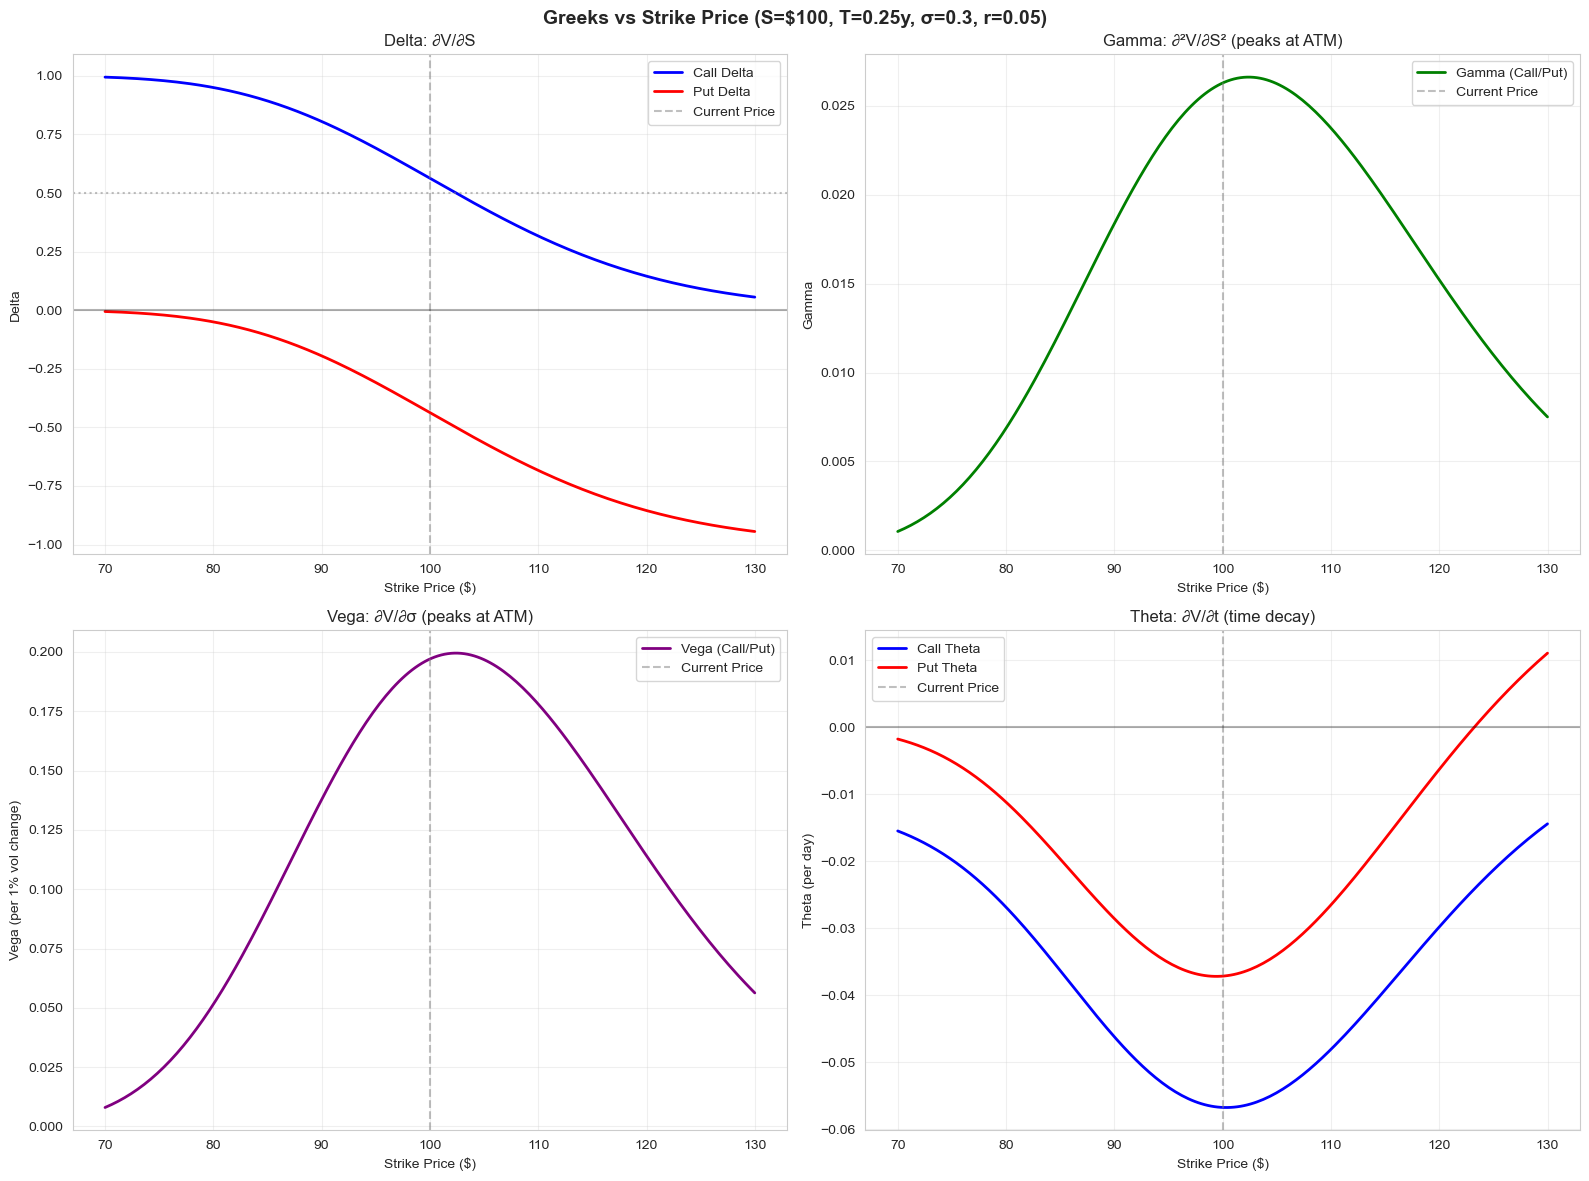

In [6]:
# Plot 1: Greeks vs Strike

def plot_greeks_vs_strike(S: float, T: float, sigma: float, r: float, q: float = 0.0,
                         strike_range: Optional[Tuple[float, float]] = None,
                         n_points: int = 200):
    """
    Plot all Greeks as a function of strike price.
    """
    if strike_range is None:
        strike_range = (S * 0.7, S * 1.3)
    
    strikes = np.linspace(strike_range[0], strike_range[1], n_points)
    
    # Calculate Greeks for calls and puts
    call_deltas, put_deltas = [], []
    gammas, vegas, call_thetas, put_thetas = [], [], [], []
    
    for K in strikes:
        call_deltas.append(AnalyticalGreeks.delta(S, K, T, sigma, r, 'call', q))
        put_deltas.append(AnalyticalGreeks.delta(S, K, T, sigma, r, 'put', q))
        gammas.append(AnalyticalGreeks.gamma(S, K, T, sigma, r, q))
        vegas.append(AnalyticalGreeks.vega(S, K, T, sigma, r, q))
        call_thetas.append(AnalyticalGreeks.theta(S, K, T, sigma, r, 'call', q))
        put_thetas.append(AnalyticalGreeks.theta(S, K, T, sigma, r, 'put', q))
    
    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'Greeks vs Strike Price (S=\\${S}, T={T}y, σ={sigma}, r={r})', 
                fontsize=14, fontweight='bold')
    
    # Delta plot
    ax1 = axes[0, 0]
    ax1.plot(strikes, call_deltas, 'b-', linewidth=2, label='Call Delta')
    ax1.plot(strikes, put_deltas, 'r-', linewidth=2, label='Put Delta')
    ax1.axvline(S, color='gray', linestyle='--', alpha=0.5, label='Current Price')
    ax1.axhline(0, color='black', linestyle='-', alpha=0.3)
    ax1.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
    ax1.set_xlabel('Strike Price ($)')
    ax1.set_ylabel('Delta')
    ax1.set_title('Delta: ∂V/∂S')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Gamma plot
    ax2 = axes[0, 1]
    ax2.plot(strikes, gammas, 'g-', linewidth=2, label='Gamma (Call/Put)')
    ax2.axvline(S, color='gray', linestyle='--', alpha=0.5, label='Current Price')
    ax2.set_xlabel('Strike Price ($)')
    ax2.set_ylabel('Gamma')
    ax2.set_title('Gamma: ∂²V/∂S² (peaks at ATM)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Vega plot
    ax3 = axes[1, 0]
    ax3.plot(strikes, vegas, 'purple', linewidth=2, label='Vega (Call/Put)')
    ax3.axvline(S, color='gray', linestyle='--', alpha=0.5, label='Current Price')
    ax3.set_xlabel('Strike Price ($)')
    ax3.set_ylabel('Vega (per 1% vol change)')
    ax3.set_title('Vega: ∂V/∂σ (peaks at ATM)')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Theta plot
    ax4 = axes[1, 1]
    ax4.plot(strikes, call_thetas, 'b-', linewidth=2, label='Call Theta')
    ax4.plot(strikes, put_thetas, 'r-', linewidth=2, label='Put Theta')
    ax4.axvline(S, color='gray', linestyle='--', alpha=0.5, label='Current Price')
    ax4.axhline(0, color='black', linestyle='-', alpha=0.3)
    ax4.set_xlabel('Strike Price ($)')
    ax4.set_ylabel('Theta (per day)')
    ax4.set_title('Theta: ∂V/∂t (time decay)')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

# Example
S, T, sigma, r = 100, 0.25, 0.30, 0.05
fig1 = plot_greeks_vs_strike(S, T, sigma, r)
plt.show()

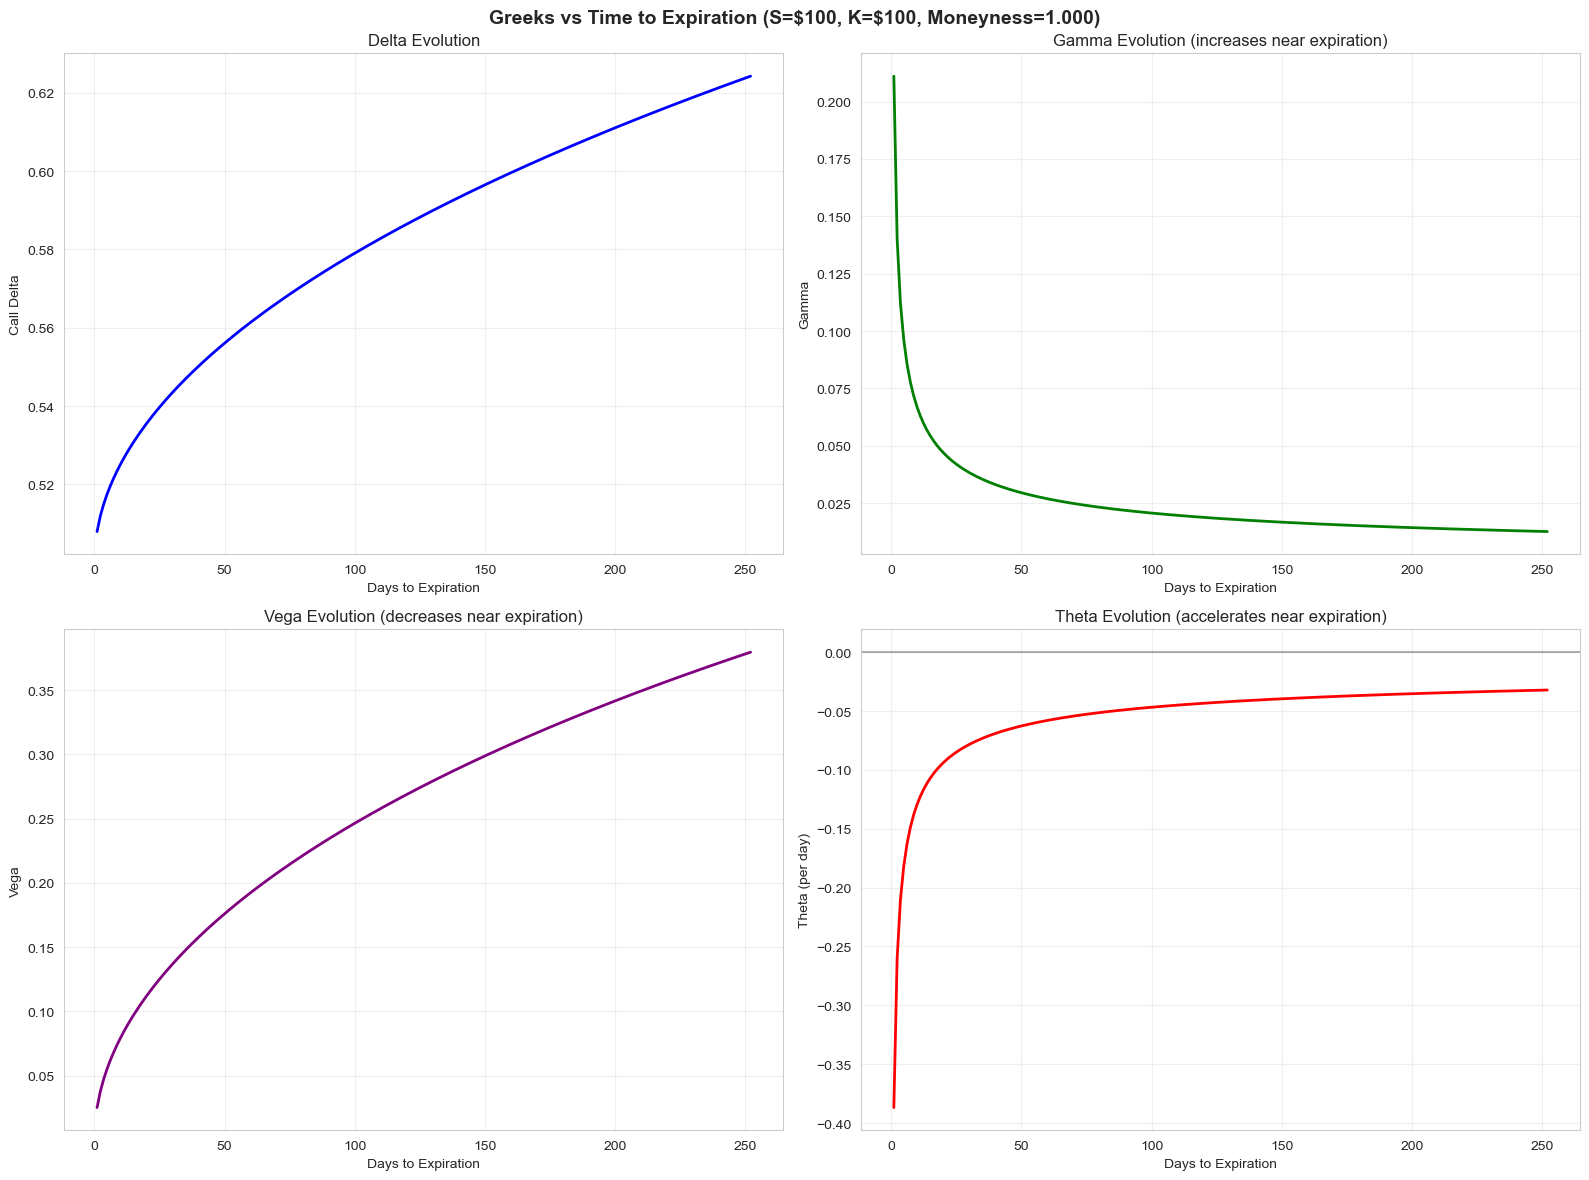

In [7]:
# Plot 2: Greeks vs Time

def plot_greeks_vs_time(S: float, K: float, sigma: float, r: float, q: float = 0.0,
                       max_days: int = 252):
    """
    Plot Greeks as a function of time to expiration.
    """
    days = np.linspace(1, max_days, 200)
    times = days / 252 # Convert to years
    
    call_deltas, gammas, vegas, call_thetas = [], [], [], []
    
    for T in times:
        call_deltas.append(AnalyticalGreeks.delta(S, K, T, sigma, r, 'call', q))
        gammas.append(AnalyticalGreeks.gamma(S, K, T, sigma, r, q))
        vegas.append(AnalyticalGreeks.vega(S, K, T, sigma, r, q))
        call_thetas.append(AnalyticalGreeks.theta(S, K, T, sigma, r, 'call', q))

    moneyness = K / S
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'Greeks vs Time to Expiration (S=\\${S}, K=\\${K}, Moneyness={moneyness:.3f})', 
                fontsize=14, fontweight='bold')
    axes[0, 0].plot(days, call_deltas, 'b-', linewidth=2)
    axes[0, 0].set_xlabel('Days to Expiration')
    axes[0, 0].set_ylabel('Call Delta')
    axes[0, 0].set_title('Delta Evolution')
    axes[0, 0].grid(True, alpha=0.3)
    
    axes[0, 1].plot(days, gammas, 'g-', linewidth=2)
    axes[0, 1].set_xlabel('Days to Expiration')
    axes[0, 1].set_ylabel('Gamma')
    axes[0, 1].set_title('Gamma Evolution (increases near expiration)')
    axes[0, 1].grid(True, alpha=0.3)
    
    axes[1, 0].plot(days, vegas, 'purple', linewidth=2)
    axes[1, 0].set_xlabel('Days to Expiration')
    axes[1, 0].set_ylabel('Vega')
    axes[1, 0].set_title('Vega Evolution (decreases near expiration)')
    axes[1, 0].grid(True, alpha=0.3)
    
    axes[1, 1].plot(days, call_thetas, 'r-', linewidth=2)
    axes[1, 1].set_xlabel('Days to Expiration')
    axes[1, 1].set_ylabel('Theta (per day)')
    axes[1, 1].set_title('Theta Evolution (accelerates near expiration)')
    axes[1, 1].axhline(0, color='black', linestyle='-', alpha=0.3)
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

# Example
S, K, T, sigma, r = 100, 100, 0.25, 0.30, 0.05
fig2 = plot_greeks_vs_time(S, K, sigma, r)
plt.show()